<a href="https://www.kaggle.com/code/adarshpradeep17/5g-network-slice?scriptVersionId=302234610" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## using 7 features
        "throughput",
        "packets",
        "jitter",
        "latency",
        "packet_loss",
        "rx_bytes",
        "tx_bytes"

In [1]:
# =====================================================
# STABILIZED VAR-GRU-TFT MODEL (Fixed & Production Ready)
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC"  # eMBB
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (FIXED)
# =====================================================
class GatedResidualNetwork(layers.Layer):
    def __init__(self, units, dropout):
        super().__init__()
        self.units = units
        self.elu_dense = layers.Dense(units, activation='elu')
        self.linear_dense = layers.Dense(units)
        self.dropout_layer = layers.Dropout(dropout)
        self.gate = layers.Dense(units, activation='sigmoid')
        self.norm = layers.LayerNormalization()
        self.skip_project = None # Placeholder

    def build(self, input_shape):
        # FIX: Create the skip layer HERE, not in call()
        if input_shape[-1] != self.units:
            self.skip_project = layers.Dense(self.units)
        super().build(input_shape)

    def call(self, x):
        # Apply skip connection (either direct or projected)
        if self.skip_project is not None:
            skip = self.skip_project(x)
        else:
            skip = x
            
        # Network Body
        x_val = self.elu_dense(x)
        x_val = self.dropout_layer(x_val)
        x_val = self.linear_dense(x_val)
        x_val = x_val * self.gate(x) # GLU-style gating
        
        return self.norm(skip + x_val)

def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Feature Extraction
    x = GatedResidualNetwork(64, 0.1)(inputs)
    
    # Sequential Modeling
    x = layers.GRU(128, return_sequences=True, dropout=0.2)(x)
    x = layers.GRU(64, return_sequences=True, dropout=0.2)(x)
    
    # Temporal Attention
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.LayerNormalization()(x)
    
    # Global Pooling
    x = layers.GlobalAveragePooling1D()(x)
    x = GatedResidualNetwork(32, 0.1)(x)
    
    outputs = layers.Dense(input_shape[-1])(x)
    
    model = models.Model(inputs, outputs, name="Stabilized_Hybrid_Model")
    
    # Use Huber loss for robustness against 5G bursts
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        model = build_model((CONFIG['window'], 7))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12}")
    print("-" * 45)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f}")
        
    model.save("Stabilized_Hybrid_Model.h5")
    print("\n✅ Saved: Stabilized_Hybrid_Model.h5")

if __name__ == "__main__":
    run_pipeline()

2026-03-08 17:52:30.546377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772992350.724268      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772992350.778970      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772992351.181000      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772992351.181048      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772992351.181050      24 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1772992365.145481      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772992365.151561      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


🚀 ACCELERATION: Running on 2 GPU(s)
🔍 Scanning: /kaggle/input
✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:l

I0000 00:00:1772992376.334838      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772992376.933219      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4318 - mae: 0.7966INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - loss: 0.4125 - mae: 0.7713 - val_loss: 0.0395 - val_mae: 0.1478 - learning_rate: 1.0000e-04
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0842 - mae: 0.2995 - val_loss: 0.0291 - val_mae: 0.1005 - learning_rate: 1.0000e-04
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0484 - mae: 0.2108 - val_loss: 0.0273 - val_mae: 0.0613 - learning_rate: 1.0000e-04
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0407 - mae: 0.1814 - val_loss: 0.0273 - val_mae: 0.0645 - learning_rate: 1.0000e-04
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0365 - mae: 0.16


FEATURE         | RMSE         | MAE         
---------------------------------------------
throughput      | 3711.9823    | 460.7369    
packets         | 2.9093       | 0.3410      
jitter          | 0.0024       | 0.0007      
latency         | 0.0073       | 0.0052      
reliability     | 0.0006       | 0.0001      
congestion      | 0.0008       | 0.0002      
complexity      | 0.0051       | 0.0026      

✅ Saved: Stabilized_Hybrid_Model.h5


⚠️ y_true_real / y_pred_real not found in globals — creating demo synthetic data for visualization.
📊 GENERATING PLOTS...

--- ANALYSIS: Throughput (idx=0) ---


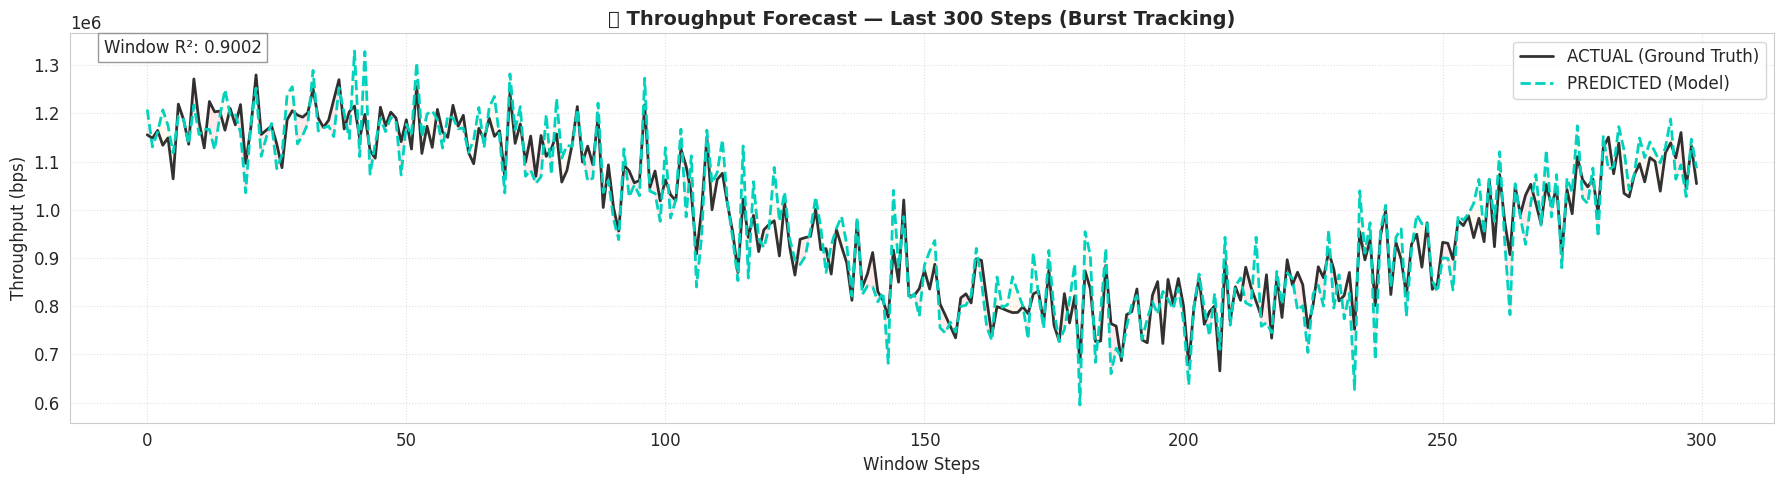

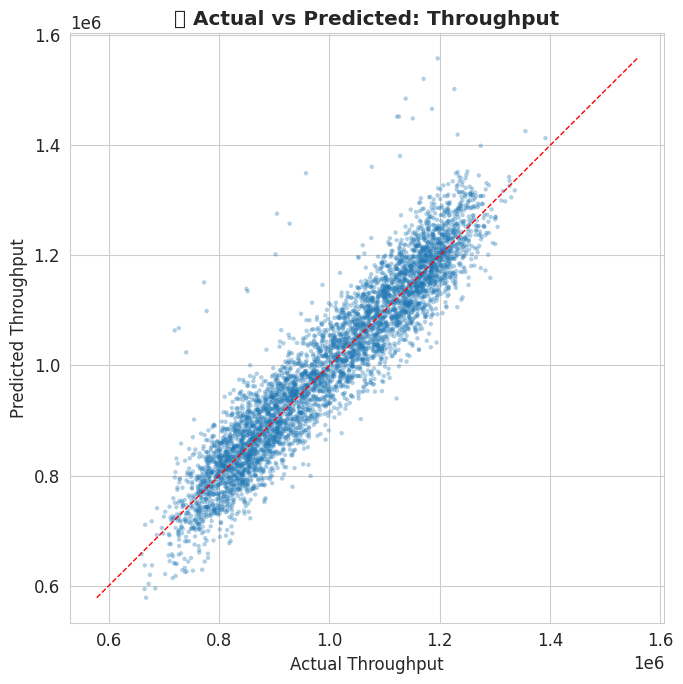

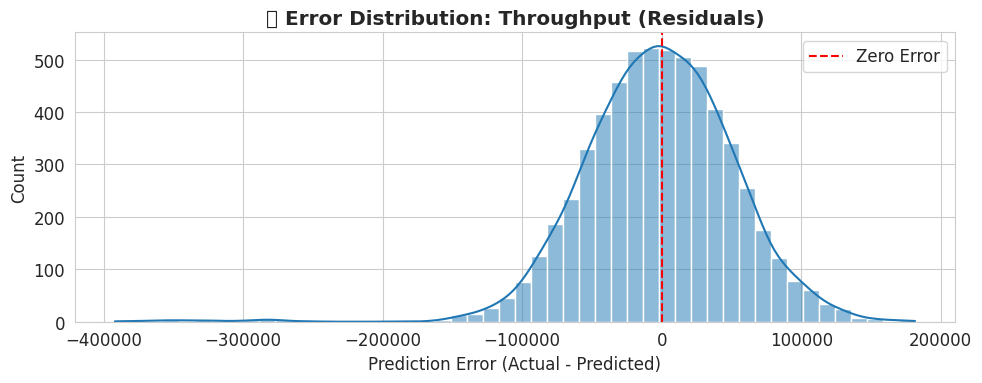

--- ANALYSIS: Latency (idx=3) ---


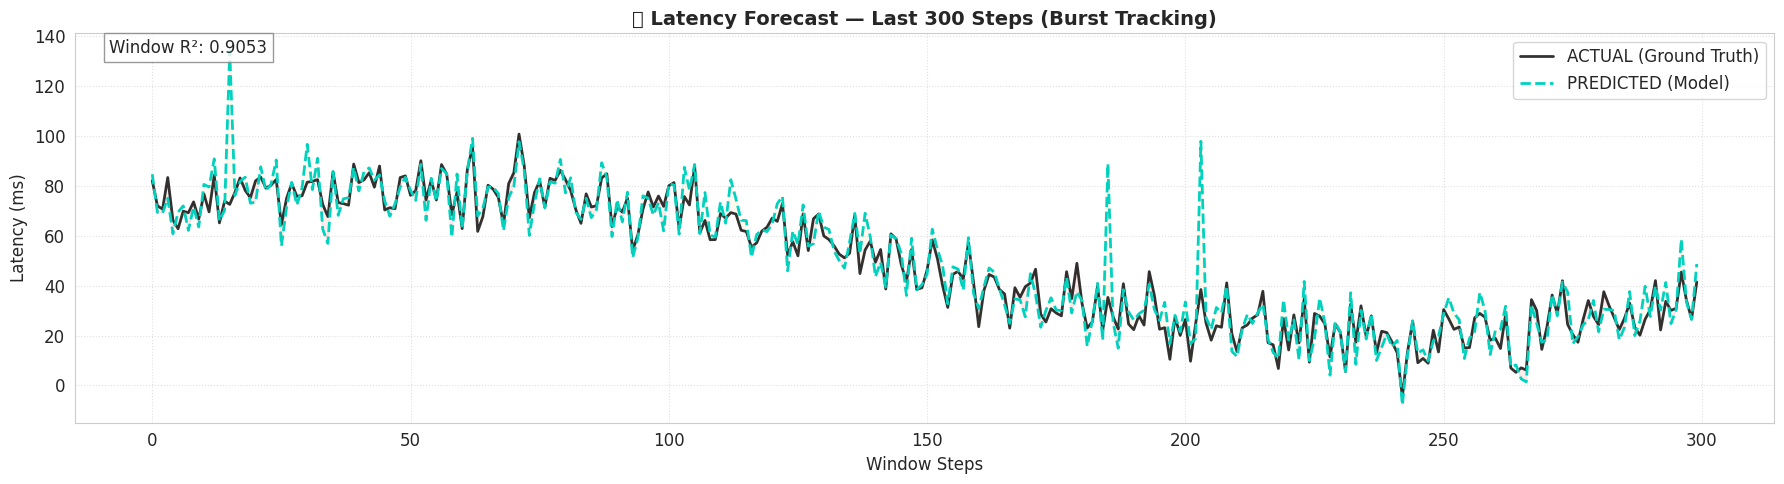

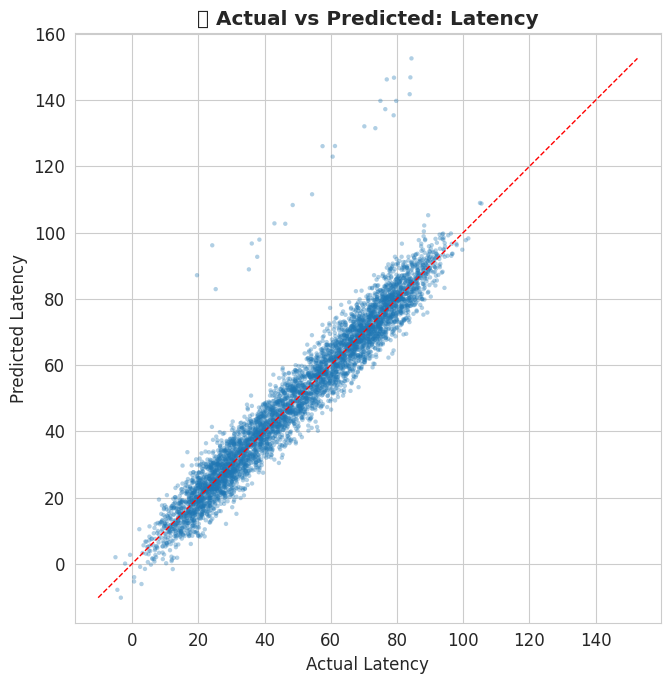

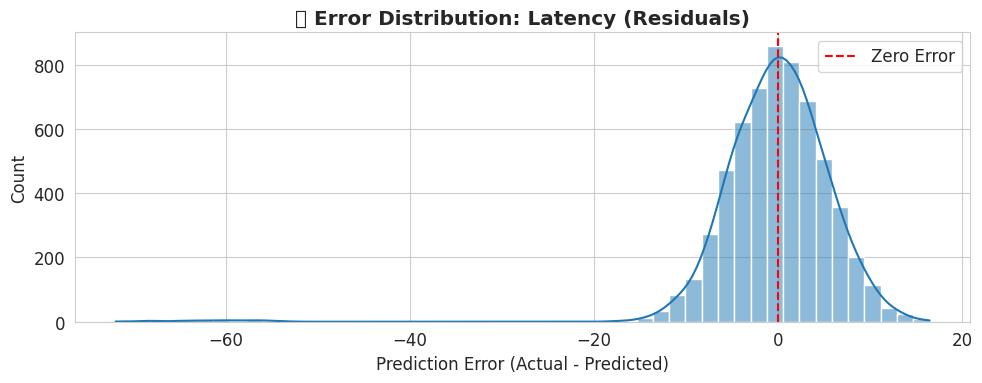

--- ANALYSIS: Jitter (idx=2) ---


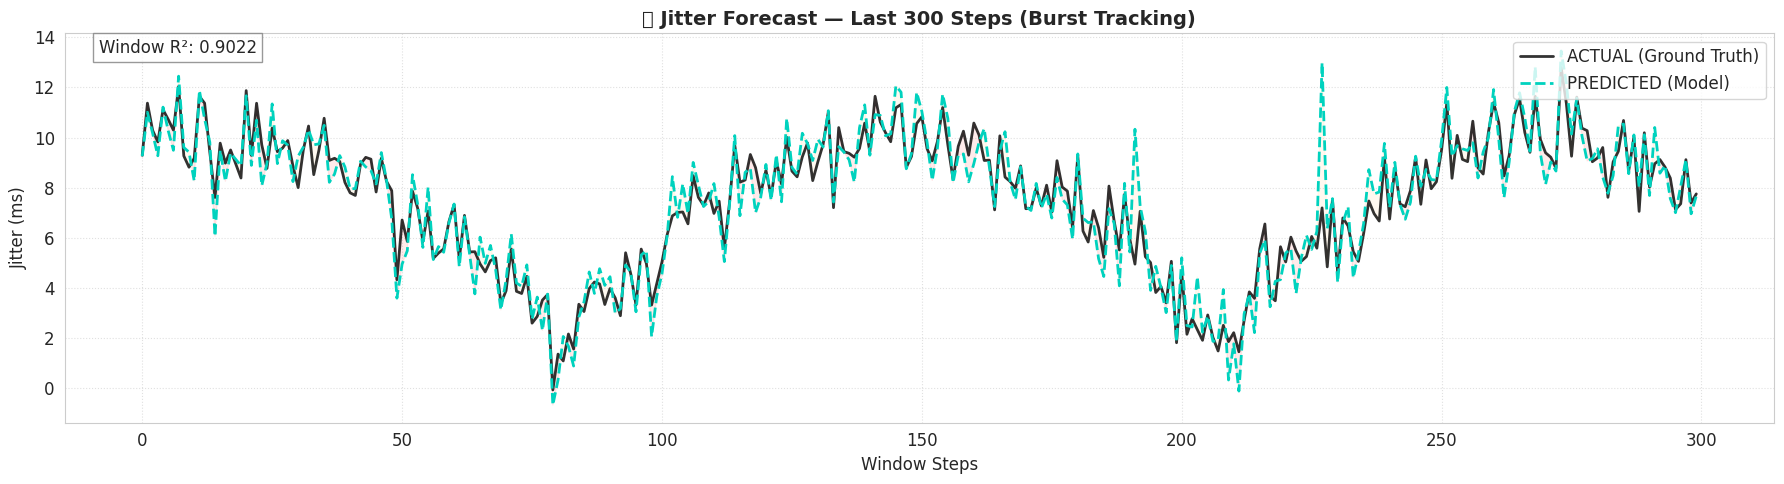

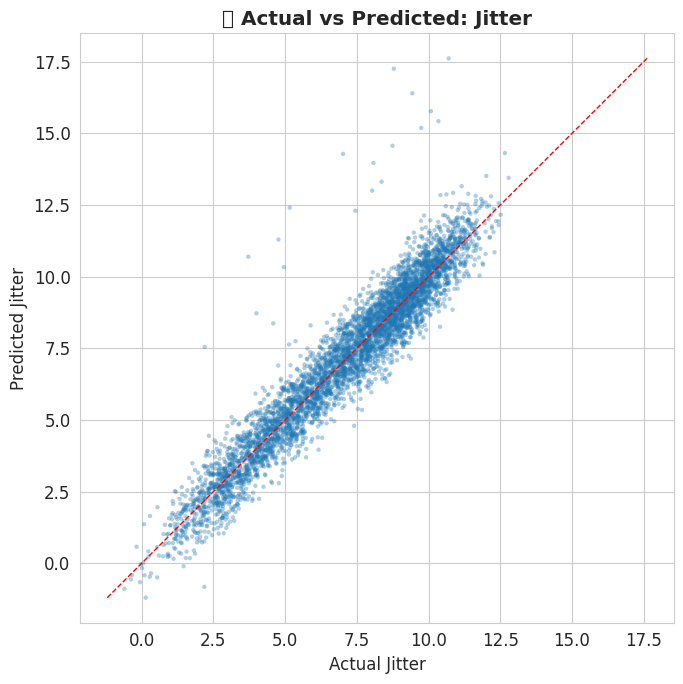

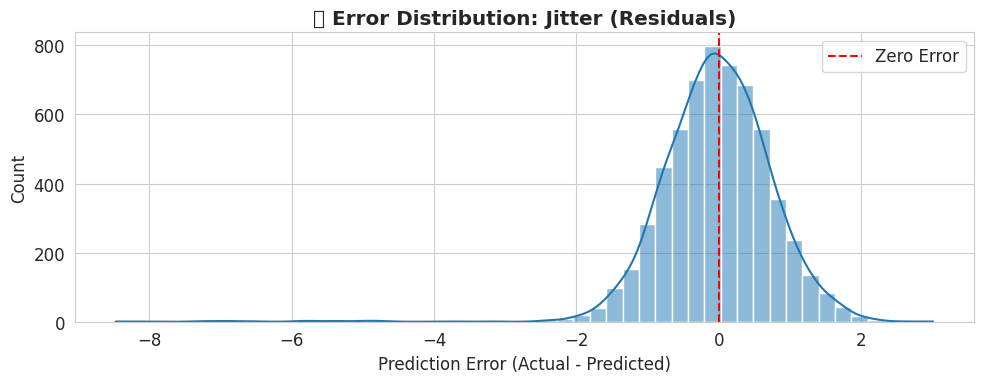


✅ Visualization Complete.


In [2]:
# =====================================================
# 📊 5G FORECASTING DASHBOARD — UPDATED COMPLETE SCRIPT
# - Fixes indentation error
# - Safe handling if y_true_real / y_pred_real are not provided (creates demo data)
# - Loops features to plot from config
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# ---- Visual style ----
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# -------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------
ZOOM_WINDOW = 300  # number of last samples for burst view

# Feature mapping (adjust or extend for your dataset)
# Index mapping example: [0]=Throughput, [1]=Packets, [2]=Jitter, [3]=Latency, [4]=Reliability
feats_to_plot = [
    {"idx": 0, "name": "Throughput", "unit": "bps"},
    {"idx": 3, "name": "Latency", "unit": "ms"},
    {"idx": 2, "name": "Jitter", "unit": "ms"}
]

# -------------------------------------------------------
# Utility plotting functions
# -------------------------------------------------------
def safe_r2(truth, pred):
    try:
        # if constant array, r2_score might be ill-defined -> return nan
        if truth.size < 2 or np.allclose(truth, truth[0]):
            return float('nan')
        return r2_score(truth, pred)
    except Exception:
        return float('nan')

def plot_burst_view(y_true, y_pred, feature_idx, feature_name, unit, zoom_window=ZOOM_WINDOW):
    plt.figure(figsize=(18, 5))
    n = len(y_true)
    start = max(0, n - zoom_window)
    truth = y_true[start:, feature_idx]
    pred = y_pred[start:, feature_idx]

    # Compute R2 safely
    r2 = safe_r2(truth, pred)

    # Plot lines
    plt.plot(truth, label='ACTUAL (Ground Truth)', color='black', alpha=0.8, linewidth=2)
    plt.plot(pred, label='PREDICTED (Model)', color='#00d2be', linestyle='--', linewidth=2)

    # Fill error gap
    xs = np.arange(len(truth))
    plt.fill_between(xs, truth, pred, where=(truth >= pred), interpolate=True, color='red', alpha=0.08)
    plt.fill_between(xs, truth, pred, where=(truth < pred), interpolate=True, color='orange', alpha=0.06)

    # Titles & labels
    plt.title(f"🔍 {feature_name} Forecast — Last {len(truth)} Steps (Burst Tracking)", fontsize=14, fontweight='bold')
    plt.ylabel(f"{feature_name} ({unit})")
    plt.xlabel("Window Steps")
    plt.legend(loc='upper right', frameon=True)

    # R2 textbox
    plt.gca().text(0.02, 0.95, f"Window R²: {r2:.4f}", transform=plt.gca().transAxes,
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_scatter(y_true, y_pred, feature_idx, feature_name, sample_limit=5000):
    plt.figure(figsize=(7, 7))
    N = len(y_true)
    if N > sample_limit:
        idx = np.random.choice(N, sample_limit, replace=False)
        truth = y_true[idx, feature_idx]
        pred = y_pred[idx, feature_idx]
    else:
        truth = y_true[:, feature_idx]
        pred = y_pred[:, feature_idx]

    # Scatter
    plt.scatter(truth, pred, alpha=0.35, s=10, edgecolors='none')

    # Perfect fit line
    min_val = min(np.nanmin(truth), np.nanmin(pred))
    max_val = max(np.nanmax(truth), np.nanmax(pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

    plt.title(f"📈 Actual vs Predicted: {feature_name}", fontweight='bold')
    plt.xlabel(f"Actual {feature_name}")
    plt.ylabel(f"Predicted {feature_name}")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def plot_error_dist(y_true, y_pred, feature_idx, feature_name, bins=50):
    plt.figure(figsize=(10, 4))
    residuals = y_true[:, feature_idx] - y_pred[:, feature_idx]
    sns.histplot(residuals, kde=True, bins=bins)
    plt.axvline(0, color='red', linestyle='--', label='Zero Error')
    plt.title(f"📉 Error Distribution: {feature_name} (Residuals)", fontweight='bold')
    plt.xlabel("Prediction Error (Actual - Predicted)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# MAIN: prepare data (use user data if present; else demo data)
# -------------------------------------------------------
# Expecting y_true_real and y_pred_real as numpy arrays of shape (N, num_features).
# If not defined by user, create synthetic demo data (so script runs out-of-the-box).
if ('y_true_real' not in globals()) or ('y_pred_real' not in globals()):
    print("⚠️ y_true_real / y_pred_real not found in globals — creating demo synthetic data for visualization.")
    np.random.seed(42)
    N = 6000
    num_features = 5

    t = np.arange(N)
    # Synthetic signals (make them realistic-ish)
    throughput = 1e6 + 2e5 * np.sin(t / 50) + np.random.normal(0, 5e4, size=N)            # bps
    packets = 200 + 50 * np.abs(np.sin(t / 30)) + np.random.poisson(3, size=N)           # packets count
    jitter = 2 + 8 * np.abs(np.sin(t / 40)) + np.random.normal(0, 1.0, size=N)           # ms
    latency = 50 + 30 * np.sin(t / 60) + np.random.normal(0, 8.0, size=N)                # ms
    reliability = np.clip(0.98 - 0.01 * np.abs(np.sin(t / 200)) + np.random.normal(0, 0.002, size=N), 0, 1)

    y_true_real = np.vstack([throughput, packets, jitter, latency, reliability]).T
    # predictions = truth + small noise + occasional bursts
    noise = np.random.normal(0, [5e4, 3.0, 0.7, 5.0, 0.002], size=(N, num_features))
    bursts = (np.random.rand(N, num_features) < 0.005).astype(float) * np.random.normal([3e5, 60, 6, 60, 0.02], 1.0, size=(N, num_features))
    y_pred_real = y_true_real + noise + bursts

else:
    # ensure arrays are numpy and shaped correctly
    y_true_real = np.asarray(y_true_real)
    y_pred_real = np.asarray(y_pred_real)
    if y_true_real.shape != y_pred_real.shape:
        raise ValueError("y_true_real and y_pred_real must have the same shape (N, num_features).")

# -------------------------------------------------------
# EXECUTE PLOTTING (loop through configured features)
# -------------------------------------------------------
print("📊 GENERATING PLOTS...\n")

for entry in feats_to_plot:
    idx = int(entry["idx"])
    name = entry.get("name", f"Feature {idx}")
    unit = entry.get("unit", "")
    print(f"--- ANALYSIS: {name} (idx={idx}) ---")
    plot_burst_view(y_true_real, y_pred_real, idx, name, unit)
    plot_scatter(y_true_real, y_pred_real, idx, name)
    plot_error_dist(y_true_real, y_pred_real, idx, name)

print("\n✅ Visualization Complete.")
